# Multi-Model Blend — LGBM + CatBoost + XGBoost

Consumes saved OOF/test probability arrays from the individual model notebooks (added as *input notebooks*), searches blend weights on OOF, then re-optimizes the class-weight decision rule on the blended probabilities.

**Model notebooks this blend consumes (attach them as input notebooks):**

- [LightGBM](https://www.kaggle.com/code/shamanthakreddymallu/s6e7-lightgbm)
- [CatBoost](https://www.kaggle.com/code/shamanthakreddymallu/s6e7-catboost)
- [XGBoost](https://www.kaggle.com/code/shamanthakreddymallu/s6e7-xgboost)

In [1]:
# PATHS
TRAIN_PATH  = '/kaggle/input/competitions/playground-series-s6e7/train.csv'
SAMPLE_PATH = '/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv'

NB_BASE = '/kaggle/input/notebooks/shamanthakreddymallu'
ARTIFACTS = {
    'lgb': (f'{NB_BASE}/s6e7-lightgbm/oof_lgb.npy',  f'{NB_BASE}/s6e7-lightgbm/test_lgb.npy'),
    'cat': (f'{NB_BASE}/s6e7-catboost/oof_cat.npy',  f'{NB_BASE}/s6e7-catboost/test_cat.npy'),
    'xgb': (f'{NB_BASE}/s6e7-xgboost/oof_xgb.npy',   f'{NB_BASE}/s6e7-xgboost/test_xgb.npy'),
}

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (balanced_accuracy_score, confusion_matrix,
                             classification_report)
from scipy.optimize import minimize
from itertools import product, combinations
import warnings
warnings.filterwarnings('ignore')

TARGET = 'health_condition'
CLASS_COLORS = {'fit': '#55A868', 'at-risk': '#4C72B0', 'unhealthy': '#C44E52'}

train = pd.read_csv(TRAIN_PATH)
le    = LabelEncoder()
y_kag = le.fit_transform(train[TARGET])
print('Class encoding:', dict(zip(le.classes_, range(3))))
print(f'Train rows: {len(y_kag):,}')

Class encoding: {'at-risk': 0, 'fit': 1, 'unhealthy': 2}
Train rows: 690,088


# Load Model Artifacts

In [3]:
MODEL_NAMES = list(ARTIFACTS.keys())
oof_stack, test_stack = [], []

for name, (oof_path, test_path) in ARTIFACTS.items():
    o, t = np.load(oof_path), np.load(test_path)
    assert len(o) == len(y_kag), f'{name}: OOF length {len(o)} != train {len(y_kag)}'
    # renormalise rows defensively (fold-averaged probs can drift from summing to 1)
    o = o / o.sum(1, keepdims=True)
    t = t / t.sum(1, keepdims=True)
    oof_stack.append(o); test_stack.append(t)
    print(f'{name}: oof {o.shape}, test {t.shape}')

N_CLASSES = 3

lgb: oof (690088, 3), test (295753, 3)
cat: oof (690088, 3), test (295753, 3)
xgb: oof (690088, 3), test (295753, 3)


# Decision-Rule Optimizer (shared)

In [4]:
def optimize_class_weights(probs, y_true, coarse=31, refine=25):
    grid       = np.exp(np.linspace(np.log(0.5), np.log(40), coarse))
    best_score = balanced_accuracy_score(y_true, probs.argmax(1))
    best_w     = np.ones(3)
    for wf, wu in product(grid, grid):
        w = np.array([1.0, wf, wu])
        s = balanced_accuracy_score(y_true, (probs * w).argmax(1))
        if s > best_score:
            best_score, best_w = s, w
    if refine:
        ff = np.linspace(best_w[1] * 0.8, best_w[1] * 1.2, refine)
        fu = np.linspace(best_w[2] * 0.8, best_w[2] * 1.2, refine)
        for wf, wu in product(ff, fu):
            w = np.array([1.0, wf, wu])
            s = balanced_accuracy_score(y_true, (probs * w).argmax(1))
            if s > best_score:
                best_score, best_w = s, w
    return best_w, best_score

# Individual Model Scores (baseline table)

In [5]:
single_results = {}
for name, o in zip(MODEL_NAMES, oof_stack):
    raw = balanced_accuracy_score(y_kag, o.argmax(1))
    w, opt = optimize_class_weights(o, y_kag)
    single_results[name] = dict(raw=raw, opt=opt, w=w)
    print(f'{name}: raw={raw:.5f}   weight-opt={opt:.5f}   weights={w.round(3)}')

BEST_SINGLE_NAME  = max(single_results, key=lambda k: single_results[k]['opt'])
BEST_SINGLE_SCORE = single_results[BEST_SINGLE_NAME]['opt']
print(f'\nBest single model: {BEST_SINGLE_NAME} ({BEST_SINGLE_SCORE:.5f})')

lgb: raw=0.92485   weight-opt=0.94759   weights=[ 1.    16.096  9.593]
cat: raw=0.94932   weight-opt=0.94948   weights=[1.    1.061 1.161]
xgb: raw=0.94698   weight-opt=0.94885   weights=[1.    2.047 2.079]

Best single model: cat (0.94948)


# Model Diversity — Pairwise Probability Correlations

The diagnostic that predicts blend value: correlations near 1.0 per class mean the models rank rows identically and blending adds nothing; ~0.95 or below leaves room.

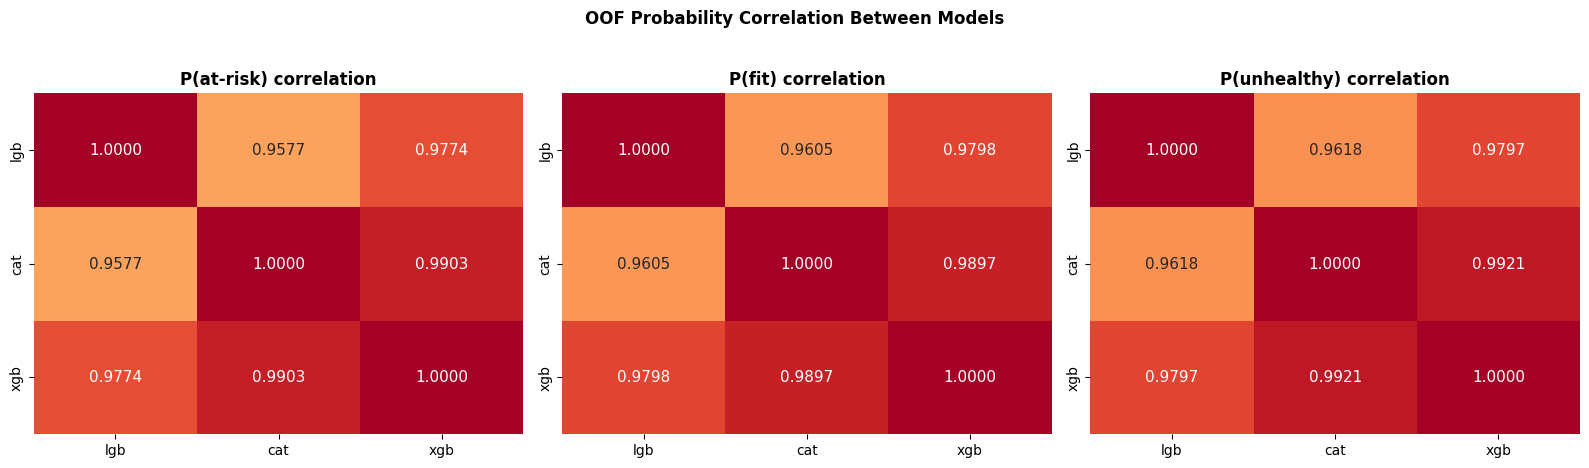

Pairwise argmax disagreement rate:
  lgb vs cat: 3.55%
  lgb vs xgb: 2.63%
  cat vs xgb: 1.08%


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for cls_idx, cls_name in enumerate(le.classes_):
    corr = np.ones((len(MODEL_NAMES), len(MODEL_NAMES)))
    for (i, oi), (j, oj) in combinations(enumerate(oof_stack), 2):
        c = np.corrcoef(oi[:, cls_idx], oj[:, cls_idx])[0, 1]
        corr[i, j] = corr[j, i] = c
    sns.heatmap(corr, annot=True, fmt='.4f', cmap='RdYlGn_r', vmin=0.85, vmax=1.0,
                xticklabels=MODEL_NAMES, yticklabels=MODEL_NAMES,
                ax=axes[cls_idx], cbar=False, annot_kws={'size': 11})
    axes[cls_idx].set_title(f'P({cls_name}) correlation', fontweight='bold')

plt.suptitle('OOF Probability Correlation Between Models', fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

# disagreement rate on argmax predictions
print('Pairwise argmax disagreement rate:')
for (i, oi), (j, oj) in combinations(enumerate(oof_stack), 2):
    d = (oi.argmax(1) != oj.argmax(1)).mean()
    print(f'  {MODEL_NAMES[i]} vs {MODEL_NAMES[j]}: {d*100:.2f}%')

# Blend Weight Search

Nelder-Mead on the simplex (as in S6E6), but the objective here is the **weight-optimized** balanced accuracy of the blend — the decision rule must be re-fit for every candidate blend because blending changes calibration (LGBM needs ~14x multipliers, CatBoost ~1x; their mix lands somewhere in between). A coarse rule fit inside the objective keeps it fast; the final rule is refit with full resolution.

In [7]:
def blend_objective(w_raw):
    w = np.abs(w_raw); w = w / w.sum()
    blended = sum(wi * p for wi, p in zip(w, oof_stack))
    _, s = optimize_class_weights(blended, y_kag, coarse=17, refine=0)  # coarse for speed
    return -s

res = minimize(blend_objective, x0=np.ones(len(oof_stack)) / len(oof_stack),
               method='Nelder-Mead',
               options=dict(xatol=1e-3, fatol=1e-6, maxiter=200))
blend_w = np.abs(res.x) / np.abs(res.x).sum()

print('Blend weights:')
for name, w in zip(MODEL_NAMES, blend_w):
    print(f'  {name}: {w:.3f}')

oof_blend  = sum(wi * p for wi, p in zip(blend_w, oof_stack))
test_blend = sum(wi * p for wi, p in zip(blend_w, test_stack))

# full-resolution decision rule on the final blend
global_w, blend_score = optimize_class_weights(oof_blend, y_kag, coarse=31, refine=25)
print(f'\nBlend OOF (weight-opt): {blend_score:.5f}')
print(f'Best single ({BEST_SINGLE_NAME}) : {BEST_SINGLE_SCORE:.5f}')
print(f'Blend gain              : {blend_score - BEST_SINGLE_SCORE:+.5f}')
print(f'Decision weights on blend: {dict(zip(le.classes_, global_w.round(4)))}')

Blend weights:
  lgb: 0.403
  cat: 0.310
  xgb: 0.287

Blend OOF (weight-opt): 0.94938
Best single (cat) : 0.94948
Blend gain              : -0.00010
Decision weights on blend: {'at-risk': np.float64(1.0), 'fit': np.float64(2.6179), 'unhealthy': np.float64(2.4517)}


## All Subsets — is the full 3-model blend actually best?

Cheap check: every 2-model pair + equal-weight variants, so the submission choice is made on evidence, not assumption. Apply the noise-band rule: differences < ~0.0005 are ties; prefer the simpler configuration on a tie.

In [8]:
results = []

# singles
for name in MODEL_NAMES:
    results.append((name, single_results[name]['opt']))

# pairs (optimized alpha via 1-D grid)
for (i, j) in combinations(range(len(MODEL_NAMES)), 2):
    best_pair = 0
    for a in np.linspace(0, 1, 21):
        blended = a * oof_stack[i] + (1 - a) * oof_stack[j]
        _, s = optimize_class_weights(blended, y_kag, coarse=17, refine=0)
        if s > best_pair:
            best_pair, best_a = s, a
    results.append((f'{MODEL_NAMES[i]}+{MODEL_NAMES[j]} (a={best_a:.2f})', best_pair))

# equal-weight 3-model
eq = sum(oof_stack) / len(oof_stack)
_, s_eq = optimize_class_weights(eq, y_kag, coarse=17, refine=0)
results.append(('equal 3-model', s_eq))

# optimized 3-model (from previous cell, full resolution)
results.append(('optimized 3-model', blend_score))

print(f'{"configuration":32s}  OOF (weight-opt)')
for name, s in sorted(results, key=lambda r: -r[1]):
    print(f'{name:32s}  {s:.5f}')

configuration                     OOF (weight-opt)
lgb+cat (a=0.15)                  0.94950
cat                               0.94948
cat+xgb (a=0.75)                  0.94943
optimized 3-model                 0.94938
equal 3-model                     0.94921
xgb                               0.94885
lgb+xgb (a=0.00)                  0.94882
lgb                               0.94759


# Post-Blend Analysis

## Confusion Matrix + Subgroup

Blend OOF Balanced Accuracy: 0.94938

              precision    recall  f1-score   support

     at-risk       0.99      0.94      0.96    592561
         fit       0.73      0.95      0.83     39803
   unhealthy       0.69      0.96      0.80     57724

    accuracy                           0.94    690088
   macro avg       0.81      0.95      0.87    690088
weighted avg       0.95      0.94      0.94    690088



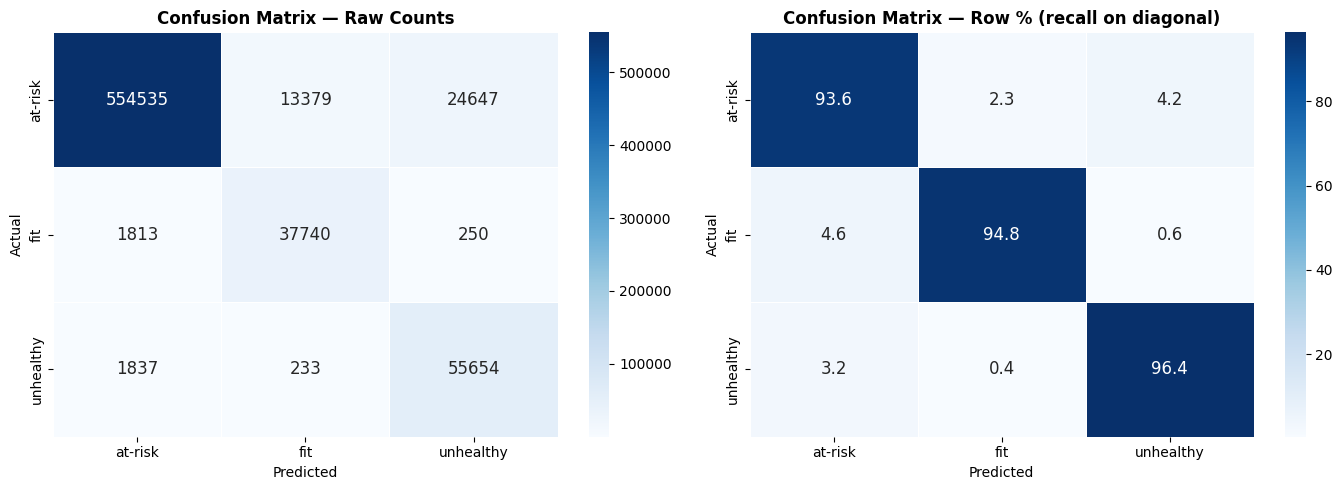

stress present  : balanced_acc = 0.96143   (n=607,277)
stress MISSING  : balanced_acc = 0.86104   (n=82,811)


In [9]:
probs_kag = oof_blend * global_w
preds_kag = probs_kag.argmax(1)

cm     = confusion_matrix(y_kag, preds_kag)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

print(f'Blend OOF Balanced Accuracy: {blend_score:.5f}')
print()
print(classification_report(y_kag, preds_kag, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[0], linewidths=0.5, annot_kws={'size': 12})
axes[0].set_title('Confusion Matrix — Raw Counts', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[1], linewidths=0.5, annot_kws={'size': 12})
axes[1].set_title('Confusion Matrix — Row % (recall on diagonal)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout(); plt.show()

# stress-missing subgroup
stress_missing = train['stress_level'].isna().values
for name, mask in [('stress present', ~stress_missing), ('stress MISSING', stress_missing)]:
    s = balanced_accuracy_score(y_kag[mask], preds_kag[mask])
    print(f'{name:16s}: balanced_acc = {s:.5f}   (n={mask.sum():,})')

## Where do the models disagree? (blend value inspection)

In [10]:
argmaxes = np.stack([o.argmax(1) for o in oof_stack])
disagree = (argmaxes != argmaxes[0]).any(0)
print(f'Rows where models disagree: {disagree.sum():,} ({disagree.mean()*100:.2f}%)')

acc_on_disagree = {}
for name, o in zip(MODEL_NAMES, oof_stack):
    acc_on_disagree[name] = balanced_accuracy_score(y_kag[disagree], o[disagree].argmax(1))
acc_on_disagree['blend'] = balanced_accuracy_score(y_kag[disagree], preds_kag[disagree])

print('\nBalanced accuracy ON DISAGREEMENT ROWS ONLY:')
for k, v in acc_on_disagree.items():
    print(f'  {k:6s}: {v:.5f}')

Rows where models disagree: 24,976 (3.62%)

Balanced accuracy ON DISAGREEMENT ROWS ONLY:
  lgb   : 0.33376
  cat   : 0.64757
  xgb   : 0.64447
  blend : 0.65333


# Submission

Saved: submission.csv (+ oof_blend.npy / test_blend.npy)

Blend weights: {'lgb': np.float64(0.403), 'cat': np.float64(0.31), 'xgb': np.float64(0.287)}
Decision weights: {'at-risk': np.float64(1.0), 'fit': np.float64(2.6179), 'unhealthy': np.float64(2.4517)}

Predicted class distribution (test):
at-risk      239649
unhealthy     34464
fit           21640

Train distribution for reference:
health_condition
at-risk      592561
unhealthy     57724
fit           39803


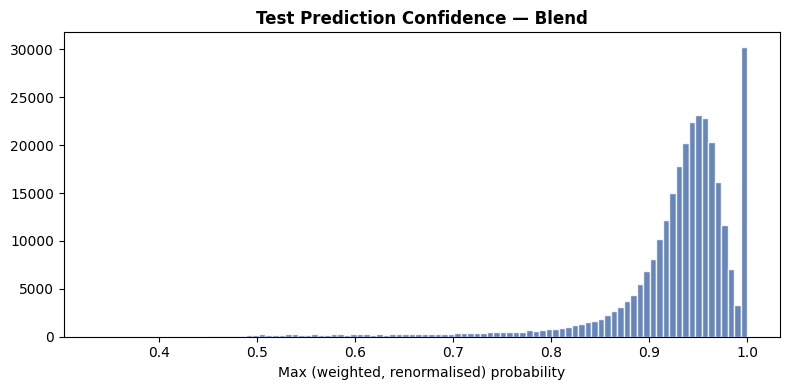

In [11]:
test_w = test_blend * global_w
labels = le.inverse_transform(test_w.argmax(1))

sub = pd.read_csv(SAMPLE_PATH)
sub[TARGET] = labels
sub.to_csv('submission.csv', index=False)

np.save('oof_blend.npy', oof_blend)
np.save('test_blend.npy', test_blend)

print('Saved: submission.csv (+ oof_blend.npy / test_blend.npy)')
print(f'\nBlend weights: {dict(zip(MODEL_NAMES, blend_w.round(3)))}')
print(f'Decision weights: {dict(zip(le.classes_, global_w.round(4)))}')
print('\nPredicted class distribution (test):')
print(pd.Series(labels).value_counts().to_string())
print('\nTrain distribution for reference:')
print(train[TARGET].value_counts().to_string())

fig, ax = plt.subplots(figsize=(8, 4))
norm_p = test_w / test_w.sum(1, keepdims=True)
ax.hist(norm_p.max(1), bins=100, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.set_xlabel('Max (weighted, renormalised) probability')
ax.set_title('Test Prediction Confidence — Blend', fontweight='bold')
plt.tight_layout(); plt.show()